# Training Process

In this section, we will go through the steps involved in training our model. We will cover the data preparation, model architecture, training loop, and evaluation metrics to understand how the model learns from the input features and distinguishes between the different classes.

The general idea is to use the classic KAN model to filter data before feeding it into the quantum model. The resulting structure of the classic model acts as a pre-processor, ensuring that the quantum model receives cleaner and more relevant data for training. This is with the purpose of improving the overall performance and efficiency of the quantum model, and use less resources during the quantum training process.

## Data preprocessing

The first step is data preparation, where we organize and preprocess the input features to ensure they are suitable for training the model. This includes normalizing the data, selecting relevant features, and splitting the dataset into training, validation, and test sets.

For this we use `scripts/run_preprocessing.py`, which contains the necessary functions to load, normalize, and split the dataset. For more details refer to the script itself and to `notebooks/EDA_top.ipynb` for an overview of the data exploration and preprocessing steps.

You can go ahead and run the preprocessing script to prepare the data for training using the CLI (Command Line Interface), or run it directly within the notebook using the following command:

```bash
python3 ../scripts/run_preprocessing.py
```

This automatically splits each partition (train, validation, and test) into 5 mutually disjoint subsets, each one with a balanced distribution of the different classes. These subsets work as statistical replicates: every training run selects one of them through its seed (`seed % 5`). The script also applies a cut in the invariant mass between 145 GeV and 205 GeV.

The flag `--full-dataset` skips the subset splitting and the invariant mass cut; the cut in the number of particles per jet is still applied.

In [ ]:
#!python3 ../scripts/run_preprocessing.py  --force

### Input features

After preprocessing, each jet is described by 22 features:
* `m`: the invariant mass of the jet, transformed with $\log(m + 1)$ and scaled with a robust scaler.
* `n`: the constituent multiplicity, standardized and clipped at $3\sigma$ so that it stays within $[-1, 1]$.
* `DR_i` and `pT_i` for $i = 1, \dots, 10$: the angular distance $\Delta R$ to the jet axis and the transverse momentum fraction of the 10 leading constituents, ordered by $p_T$. The number of constituents comes from the cut in the number of particles per jet described in `notebooks/EDA_top.ipynb`.

The invariant mass window of 145 GeV to 205 GeV is centered around the top-quark mass ($m_t \approx 173$ GeV), where the signal jets concentrate. In this region the background jets resemble the signal more closely, which keeps the classification focused on the most relevant part of the phase space.

## Classic KAN

The classic workflow consists of 3 main steps:
1) train a classic baseline,
2) prune nodes and edges to keep the most relevant structure,
3) retrain the pruned structure.

At this point the process splits into 2 separate branches, both starting from the retrained model: one for further classic processing and one for quantum model training.

**Classic branch**

This branch continues with further classic processing, using the pruned and retrained structure to fit the B-splines into analytic formulas for a classic interpretation. A final fine-tuning step adjusts the parameters of these formulas.

**Quantum branch**

This branch takes the pruned and retrained classic model as the starting point for quantum model training, ensuring that the quantum model receives cleaner and more relevant data. The focus is to adjust the B-splines into 2 different bases, Chebyshev and sine; here we also implement a random initialization for the quantum model parameters to compare the performance with the warm-start initialization.

### Baseline training

After transforming and preprocessing the data, we can run the classic baseline based on [the pykan library](https://github.com/kindxiaoming/pykan), and optimize and modify the model structure as needed in `src/architectures/hep_kan.py`. In `hep_kan.py` we define the architecture with a focus on improving the logic and RAM usage when plotting the function of each edge and during the fitting process, to avoid spending excessive computational resources and time. To avoid using excessive resources and stalling the training process, we also limit the number of input samples passed through the hidden layers during the training phase. This approach ensures that the classic model remains efficient and manageable, providing a solid foundation for subsequent quantum model training.

**Due to limited computational resources, this strategy is crucial for maintaining a balance between model complexity and practical feasibility.**

The training loop is in `src/architectures/classic_kan.py`. All the classic steps are condensed into `scripts/train_kan.py`.

You can delete the "#" symbol in the next cell to run the sample training command. You can change the seed value as you like.

```bash
!python3 ../scripts/train_kan.py --seed 10
```

In [ ]:
# sample
#!python3 ../scripts/train_kan.py --seed 10

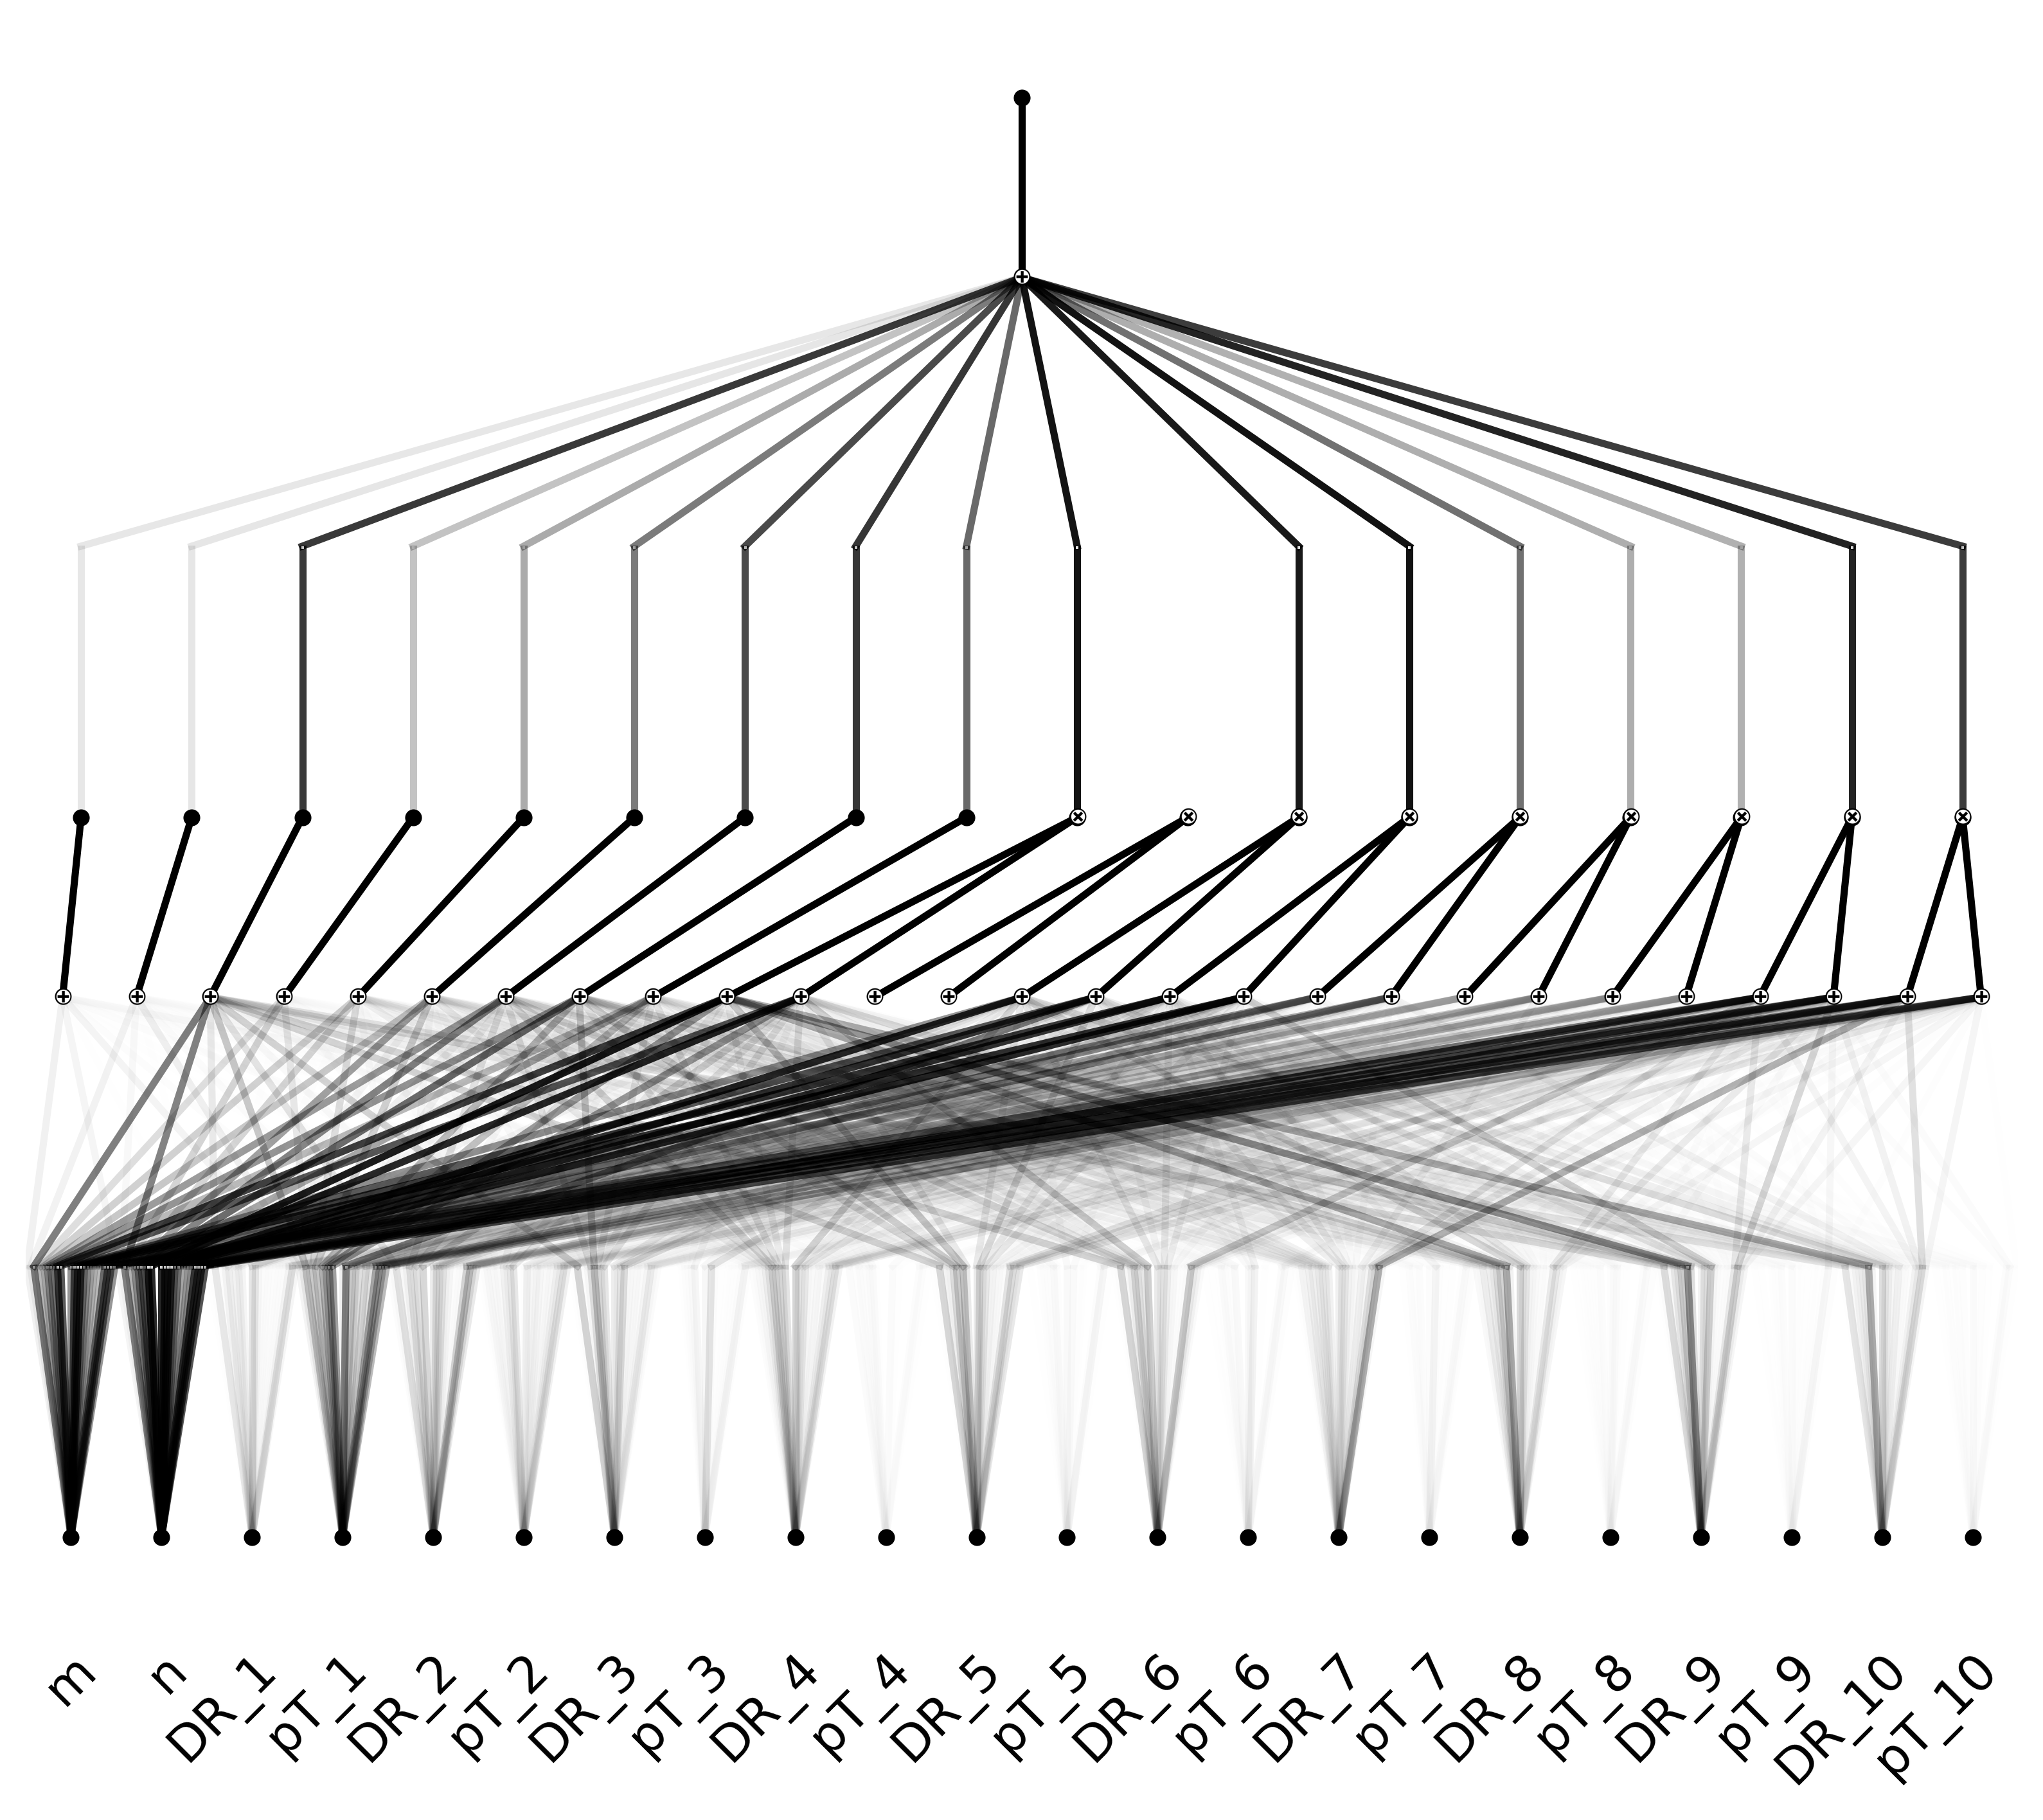

In [3]:
# show initial model plot
from IPython.display import Image
Image("../outputs/top/mass_cut/n5_subset0/seed_10/plots/01_plot_base/base_model.png")

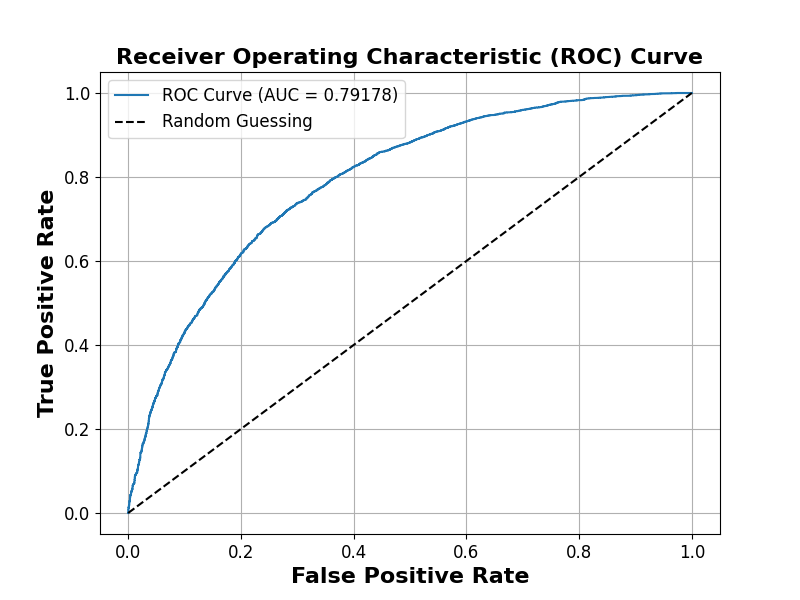

In [18]:
# show base evaluation ROC curve
from IPython.display import Image
Image("../outputs/top/mass_cut/n5_subset0/seed_10/plots/01_plot_base/base_eval_roc.png")

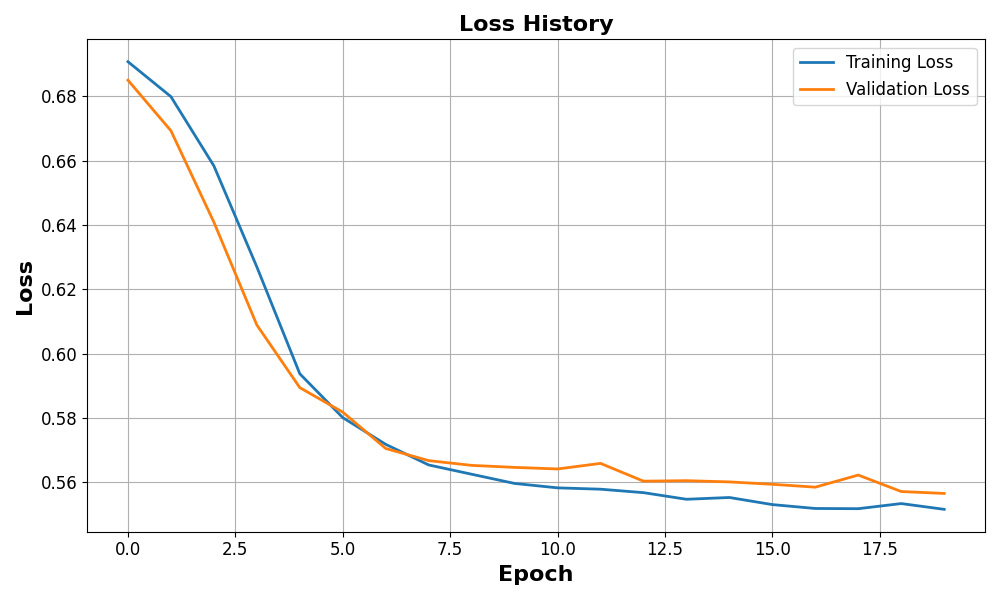

In [19]:
# show base training loss image
from IPython.display import Image
Image("../outputs/top/mass_cut/n5_subset0/seed_10/plots/01_plot_base/base_train_loss.png")

**Architecture of the classic model and parameters [22, [9, 9], 1]**

For the training process we select 3 levels/layers.
1) Input layer: receives the preprocessed data and passes it to the hidden layer. The initial number of features is 22.
2) Hidden layer: processes the input data, selecting the most relevant features and representations. Here the model takes the previous layer's output as input with 9 possible addition nodes and 9 possible multiplication nodes, [9, 9].
3) Output layer: produces the final prediction based on the processed information from the hidden layer. It has a single output dimension.

**Importance of multiplication nodes**

The original Kolmogorov-Arnold Theorem says:

> Any multivariate continuous function, $f:[0,1]^n \to \mathbb{R}$, can be represented as a superposition of continuous functions of one variable and addition.

The multiplication nodes are essential for capturing interactions between features, as they allow the model to represent products of features directly, without having to build them from additive combinations alone.

**Training hyperparameters**

All the classic stages use a B-spline grid of 5 intervals with order $k = 3$. The main training values for each stage are:

| Stage | Learning rate | Max epochs | Batch size | Early-stop patience | Min delta |
|---|---|---|---|---|---|
| Base training | $5 \times 10^{-3}$ | 60 | 4096 | 7 | $10^{-2}$ |
| Retraining after pruning | $10^{-3}$ | 20 | 2048 | 6 | $5 \times 10^{-5}$ |
| Symbolic fine-tuning | $5 \times 10^{-5}$ | 15 | 2048 | 5 | $10^{-6}$ |

All values are defined in `src/utils/hyperparams.py`.

### Prune and fine-tuning

After training the initial classic model, we prune it, retrain the remaining structure, and subsequently use it as the starting point for the quantum model training. This ensures that the quantum model benefits from a well-optimized and resource-efficient classic foundation. The idea behind this approach **is that** the model **selects** the most relevant features and representations learned during the baseline training, providing a strong starting point for the quantum model to build upon. The hidden layer of the classic model is the one responsible for the number of qubits required, which is why it was also important to keep only the two most significant inputs for each hidden node. Here we select the 2 most relevant inputs from the previous layer to feed each node of the hidden layer of the quantum model.

**Regularization as the pruning driver**

During the baseline training, the loss includes the sparsity regularization of pykan with an overall weight $\lambda = 0.01$, combining an L1 term ($\lambda_{L1} = 0.01$), an entropy term ($\lambda_{entropy} = 0.01$), and two terms over the spline coefficients ($\lambda_{coef} = 0.005$, $\lambda_{coefdiff} = 0.01$). These terms push the activation functions with low contribution toward zero, which makes them easy to identify and remove.

**Pruning criteria**

The pruning step (`prune_and_save_kan` in `src/architectures/classic_kan.py`) applies 4 filters, based on the attribution scores computed over a sample of the training data:
* Inputs with a score below $10^{-2}$ are removed.
* Hidden nodes with a score below $4 \times 10^{-2}$ are removed.
* Edges with a score below $6 \times 10^{-2}$ are removed.
* A hard cap keeps at most 2 input edges per hidden node (`prune_max_fanin = 2`), ranked by attribution score. This cap limits the number of qubits and gates in the quantum circuit.

**Retraining**

The pruned model is retrained with a lower overall weight ($\lambda = 0.001$) and stronger L1 and entropy terms ($\lambda_{L1} = 0.1$, $\lambda_{entropy} = 0.2$), so the surviving structure adapts to the removed connections while it stays sparse.

**Pipeline stages**

Each step of `scripts/train_kan.py` saves its own checkpoint and plots, so every stage can be inspected separately:

| Step | Checkpoint | Description |
|---|---|---|
| 1 | `01_base` | Baseline training |
| 2 | `02_pruned` | Pruned model |
| 3 | `03_retrained` | Retrained pruned model, starting point of both branches |
| 4 | `04_symbolic` | Symbolic formulas fitted to the edges |
| 5 | `05_final` | Symbolic model after fine-tuning |

### Symbolic fitting and fine-tuning

One of the main advantages of the KAN architectures is the **interpretability** it offers. By explicitly modeling both additive and multiplicative interactions between features, and also a symbolic fitting option, the model provides clear insights into how different features contribute to the final predictions. This transparency allows researchers to better understand the underlying relationships in the data and facilitates more informed decision-making based on the model's outputs.

**How the symbolic fit works**

Starting from the `03_retrained` checkpoint, every active edge is compared against each function of the symbolic library using a sample of the training data. Each candidate receives a score that balances the quality of the fit ($R^2$) and the simplicity of the function, with a weight `symbolic_weight_simple = 0.5`. The candidate with the best score is fixed on the edge only if its $R^2 \geq 0.85$; otherwise the edge is fixed to the identity function $x$. After the fit, a short fine-tuning step ($5 \times 10^{-5}$ learning rate, up to 15 epochs) adjusts the parameters of the symbolic formulas.

For example, we can obtain architectures like this:

In [ ]:
# show an image
from IPython.display import Image
Image("../outputs/top/mass_cut/n5_subset0/seed_10/plots/05_final/final_model.png")


At the bottom are the input features, while the top represents the final output of the model. This layout helps in understanding how each input contributes to the final prediction through the various layers and interactions modeled by the KAN architecture.

## Information transfer

The information transfer connects the classic and quantum branches. The extractor reads the `03_retrained` checkpoint, so it works with the numerical B-splines before the symbolic fit, and builds the graph that defines the quantum circuit:
1. For every active input-to-hidden edge and every hidden-to-output edge, the response of the edge is isolated and fitted with the selected basis (see the Chebyshev and sine fitting sections below).
2. Edges with a dynamic range (maximum minus minimum of the response) below $10^{-3}$ are discarded, since they carry almost no information.
3. Each group of edges that feeds a hidden node receives a dedicated wire, which sets the number of qubits of the circuit.
4. The number of qubits, the active inputs, the hidden nodes with their type (addition or multiplication), the output edges, and the fitted coefficients are serialized into `quantum_weights.pt`.

## Quantum model

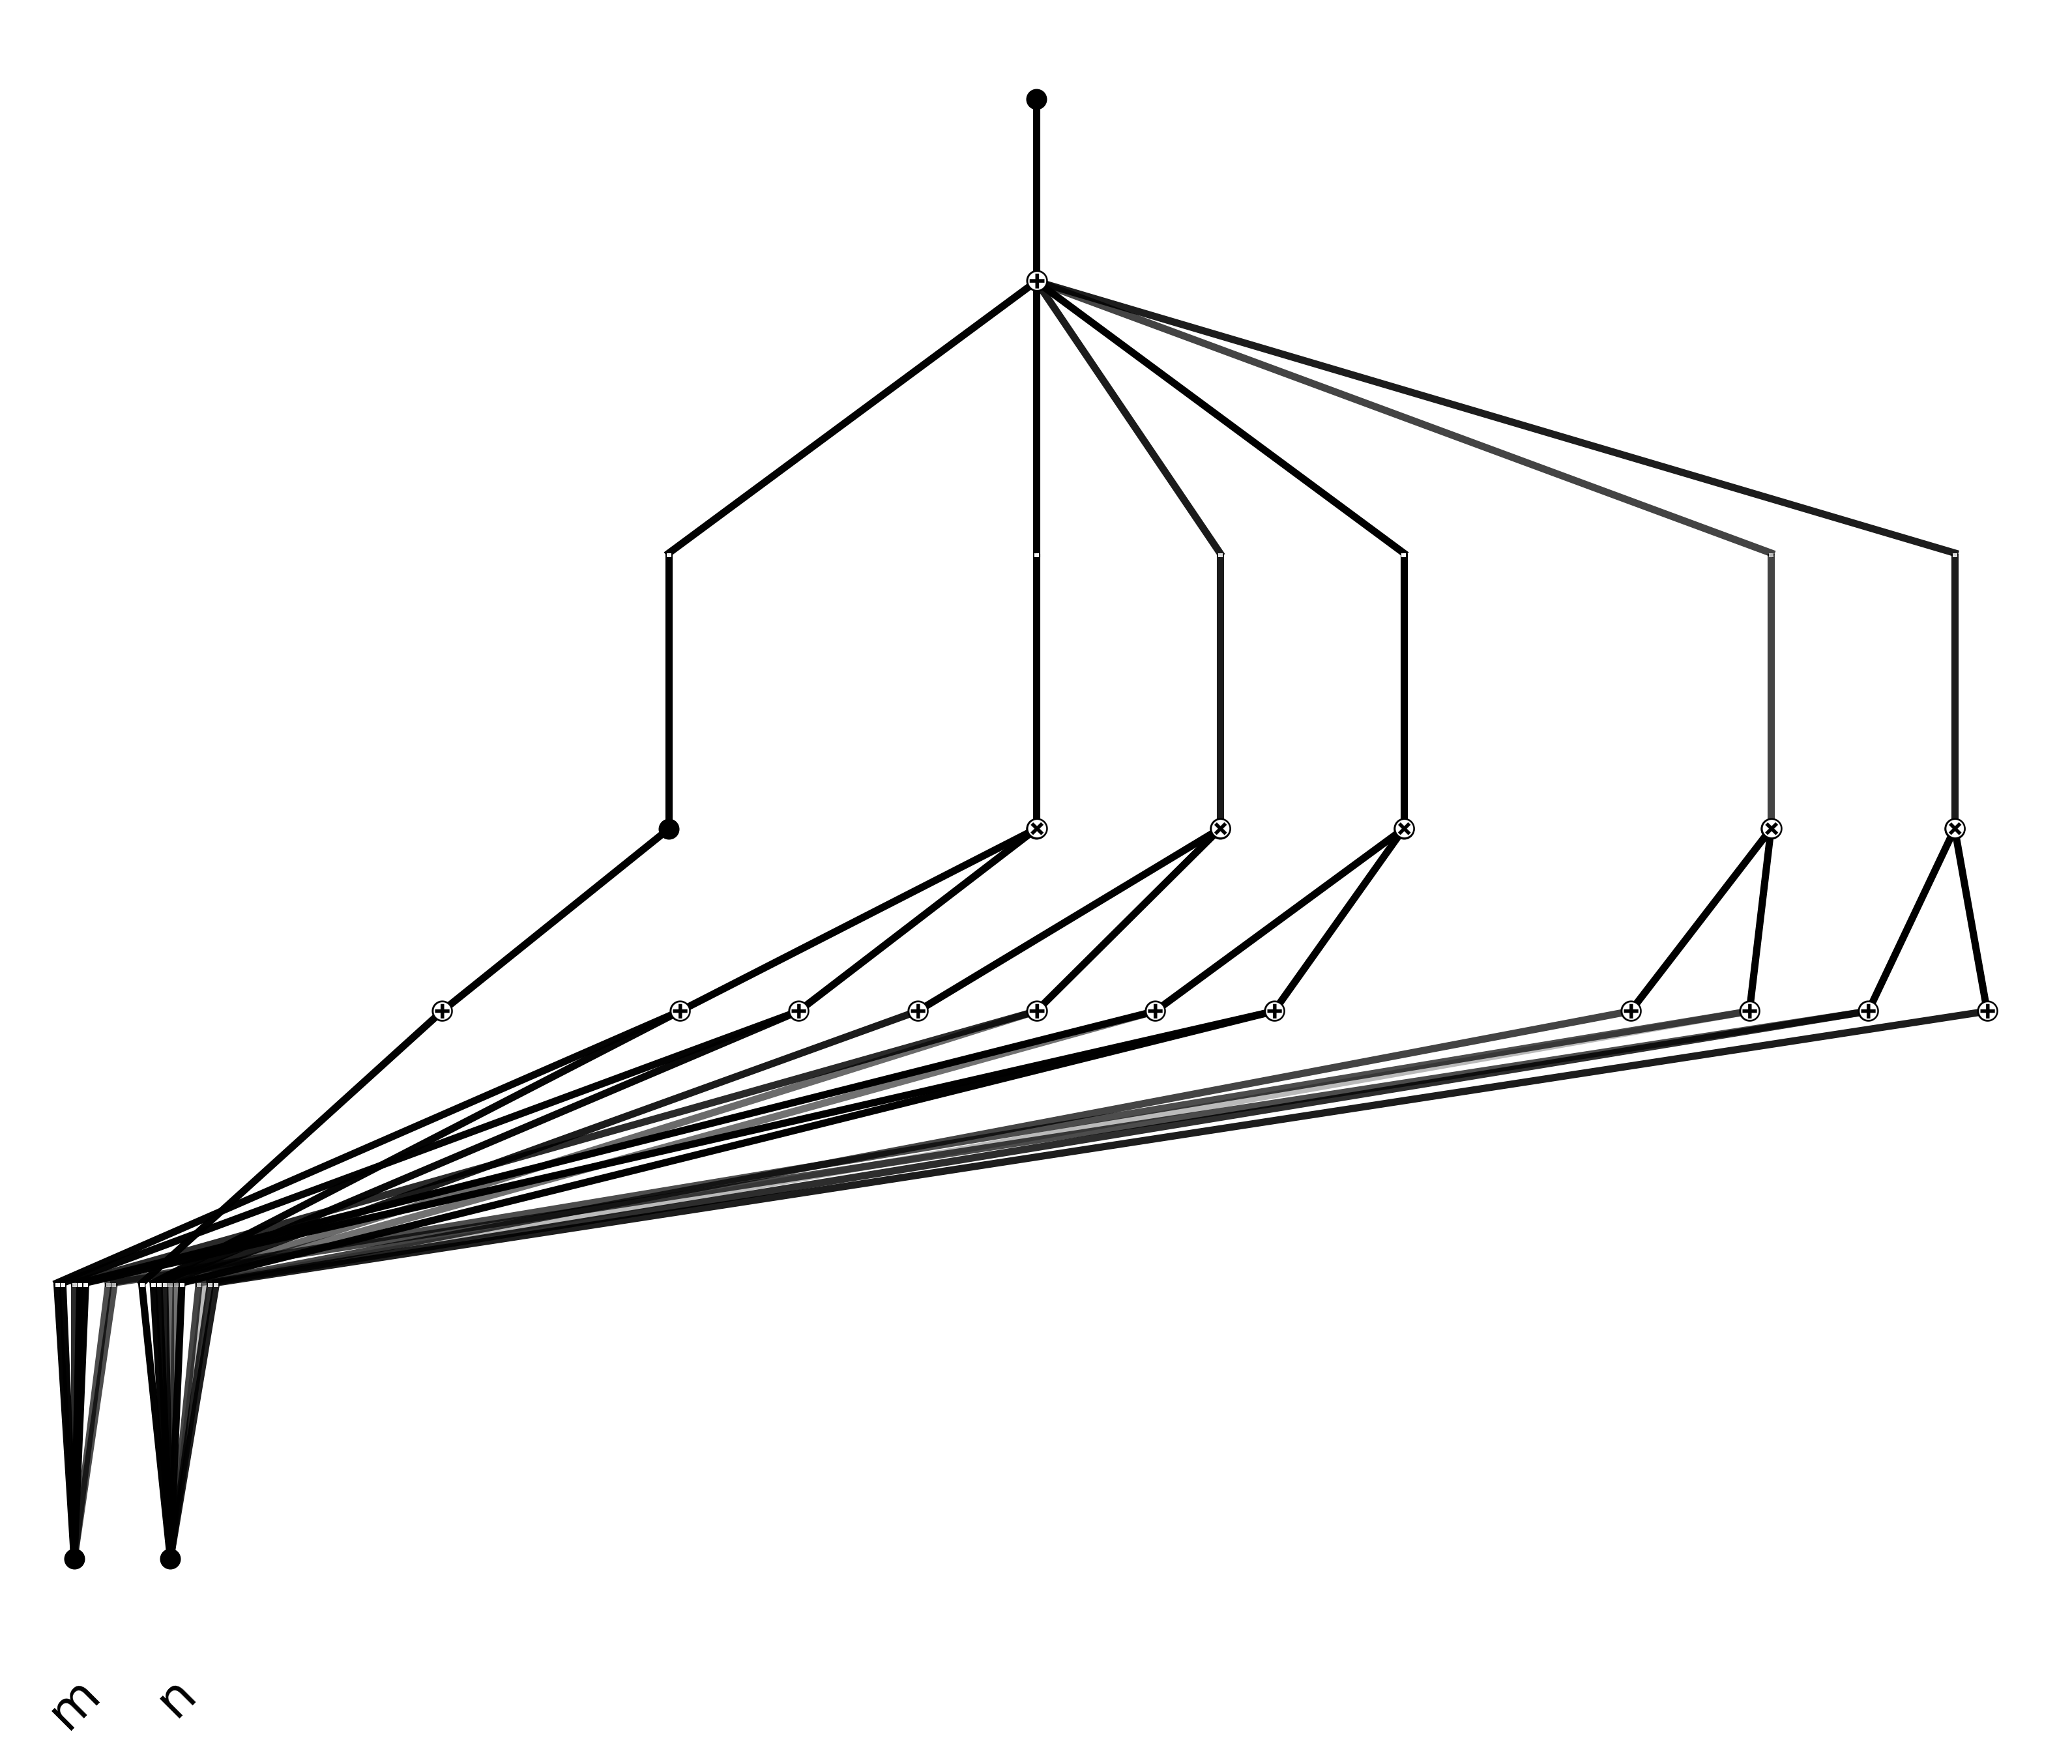

In [4]:
# show image
from IPython.display import Image
Image("../outputs/top/mass_cut/n5_subset0/seed_10/plots/03_retrained/retrained_model.png")

This image represents the initial structure for the quantum KAN model. 1 addition node and 5 multiplication nodes are responsible for combining the input features in the network and give us the number of qubits we will use for the quantum circuit.

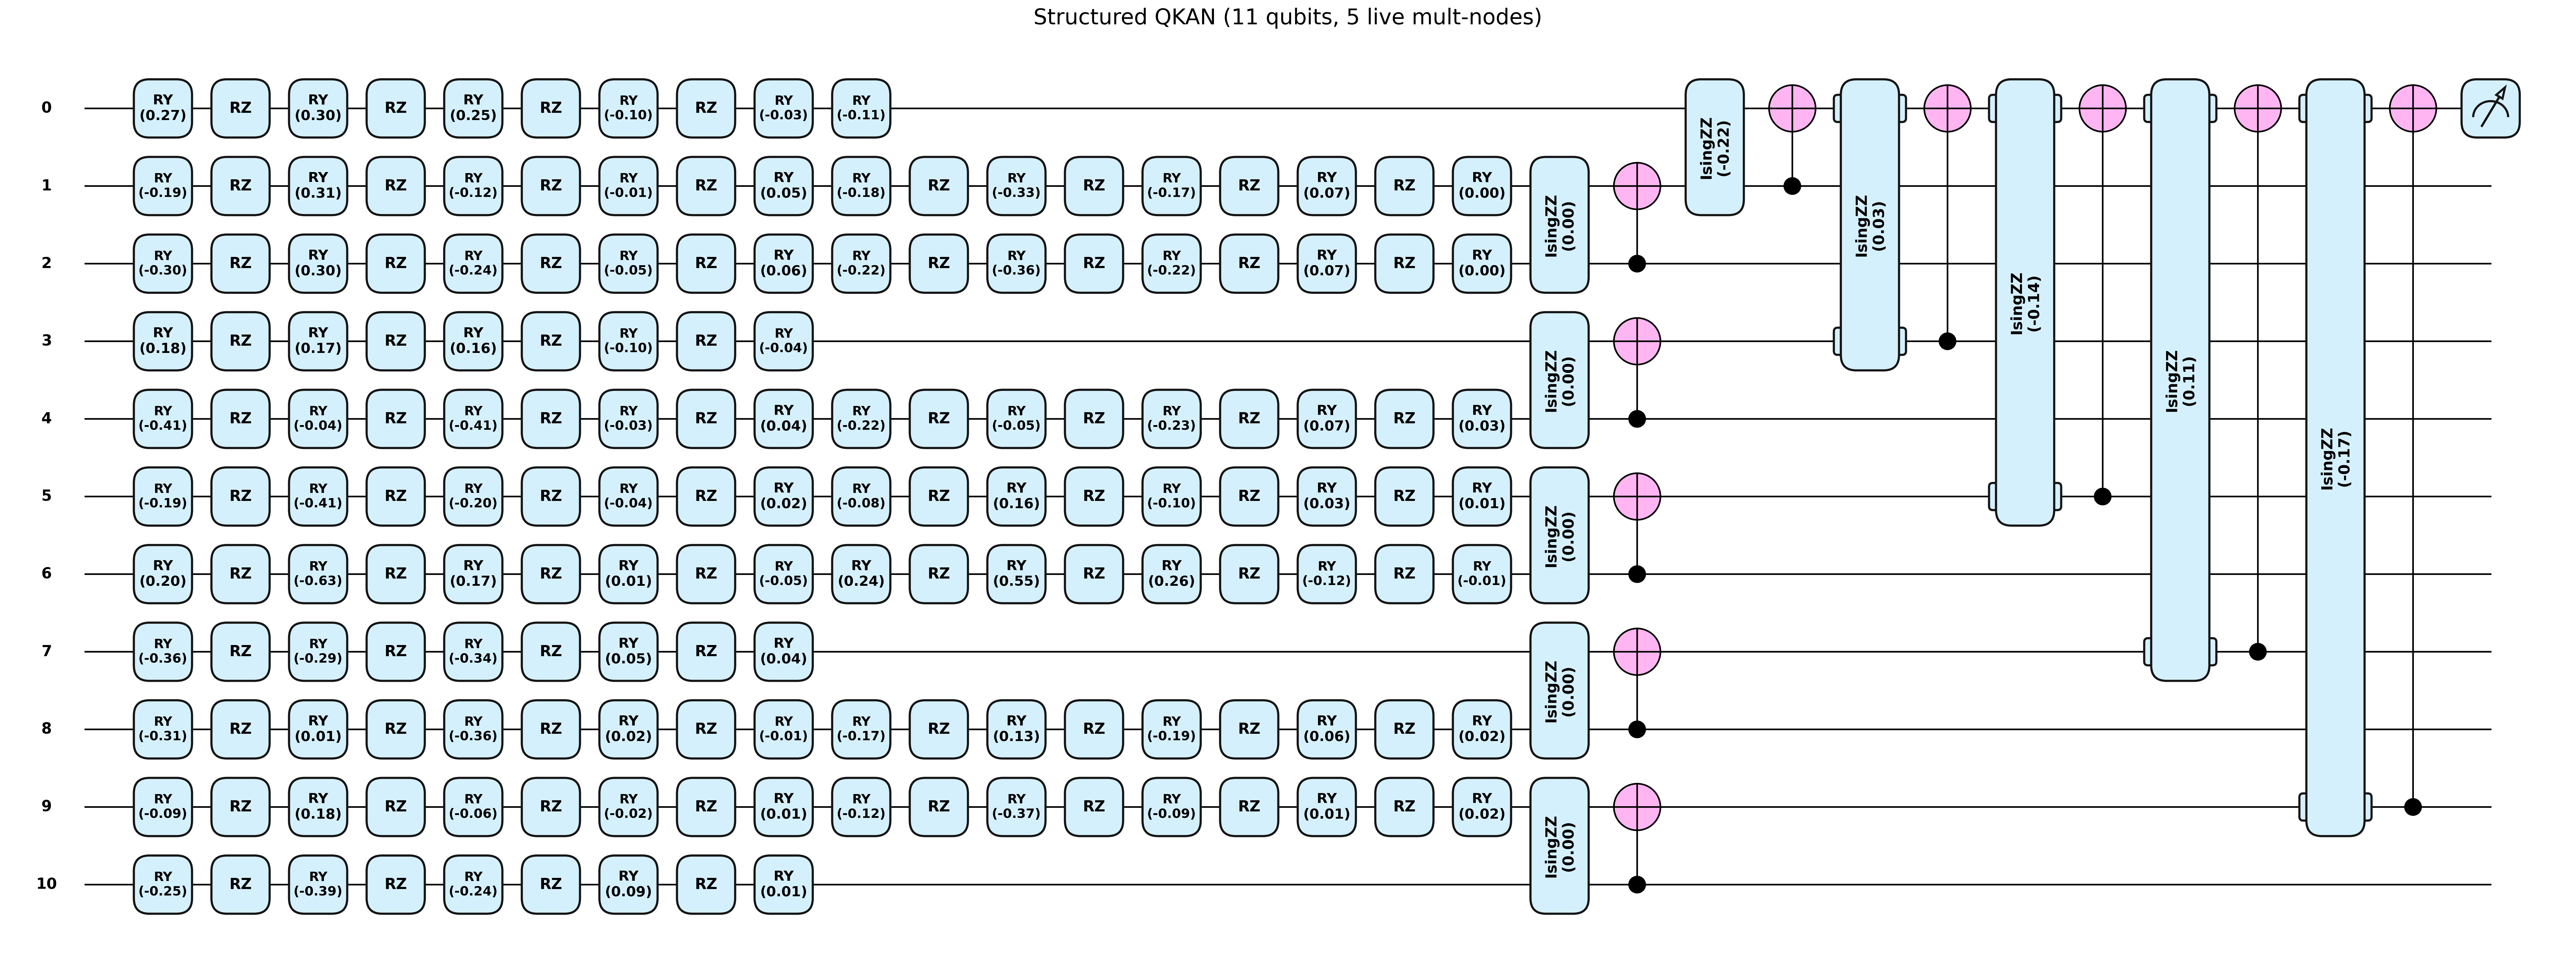

In [22]:
# show image
from IPython.display import Image
Image("../outputs/top/mass_cut/n5_subset0/seed_10/plots/quantum-circuit.png")

Here the idea for the architecture is based on:
1) use the Data Re-Uploading (DRU) technique to model each edge function,
2) the hidden layer decides which features are important and the number of qubits,
3) the addition nodes are represented as consecutive DRU applications of the input features on the same wire,
4) the multiplication nodes are represented with an IsingZZ gate followed by a CNOT gate,
5) all the information is propagated through the network using these quantum operations and collapsed into one single wire with IsingZZ + CNOT gates.

**Encoding the Chebyshev basis in the circuit**

Each input $x$ is encoded as the angle $\theta = \arccos(x)$, with $x$ clipped to $[-0.9999, 0.9999]$. This choice links the circuit to the Chebyshev polynomials, since $T_n(x) = \cos(n \arccos x)$, and it requires the inputs to lie in $[-1, 1]$.

* Each edge applies 4 repetitions (the Chebyshev degree) of an $R_Y(w_i)$ rotation followed by an $R_Z(\theta)$ rotation, plus a final $R_Y$, giving 5 trainable weights per edge.
* $R_Z$ rotations on the same wire add their angles, which is how the addition nodes accumulate the contributions of their inputs.
* For multiplication nodes with more than two inputs, the chain of IsingZZ gates is an approximation of the product.
* The readout is the expectation value $\langle Z \rangle \in [-1, 1]$ on the output wire, used directly as the logit. After the sigmoid, the predicted probabilities stay within about $[0.27, 0.73]$. This limits the calibration of the probabilities and leaves the ranking of the events, and therefore the AUC, unaffected.

### Quantum Implementation Details

The implementation consists of two core blocks:
1. **Model Definition (`src/architectures/qkan_model.py`)**: Defines the `QKANModel` PyTorch module, which builds the dynamic PennyLane circuit based on the extracted graph structure. It parses the active input-to-hidden edge map and configures either the Chebyshev or the sine basis mapping, applying Data Re-Uploading (DRU). Multiplication nodes are mapped using entangling blocks (`IsingZZ` + `CNOT` gates).
2. **Hybrid Training Loop (`src/architectures/quantum_kan.py`)**: Defines the `QuantumKANTrainer`, which implements mini-batch training using the `Adam` optimizer and a learning rate scheduler (`ReduceLROnPlateau`), and handles logging/checkpoints. It allows switching between three simulation backends: `"ideal"`, `"shots"`, and `"noisy"`.

**Simulation backends**

* `ideal`: `lightning.qubit`, exact expectation values. All the training runs use this backend.
* `shots`: `default.qubit` with 1024 shots, which adds the statistical noise of a finite number of measurements.
* `noisy`: Qiskit Aer density-matrix simulator with the noise model of the `FakeManilaV2` backend and 1024 shots. Manila is a 5-qubit device, which reinforces the need for a strong pruning of the classic model.

The quantum training process consists of two primary types of execution:

1. **Agnostic Baseline Comparative Evaluation**: Before any quantum parameter optimization happens, we can evaluate and compare the predictive signal that survives the classical-to-quantum extraction step. Using different mathematical bases (Chebyshev, sine) or starting from a completely random initialization, we score the models on the ideal simulator. This is achieved via the script `scripts/eval_sine_baseline.py`.
2. **Quantum Fine-Tuning**: Once the classical KAN topology/coefficients have been extracted, we fine-tune the variational parameters on a quantum simulator backend (`ideal`, `shots`, or `noisy`). This is executed using the `scripts/train_qkan.py` script.

Uncomment any of the following commands in the cells below to run these stages:

In [ ]:
# Evaluate baseline initializations (Chebyshev vs Sine vs Random VQC init) with NO training
#!python3 ../scripts/eval_sine_baseline.py --seeds 10 --task top

In [ ]:
# Run standard Chebyshev-basis warm-start QKAN model training (e.g. ideal backend)
#!python3 ../scripts/train_qkan.py --seed 10 --task top --train_backend ideal

In [ ]:
# Run random-VQC-initialized baseline model training (ablation study)
#!python3 ../scripts/train_qkan.py --seed 10 --task top --random_init

**Evaluation protocol**

`scripts/train_qkan.py` evaluates the warm-started circuit on the test set with the three backends before any quantum training (baseline), then trains it, and evaluates it again with the three backends (final). This gives a baseline/final by ideal/shots/noisy grid, which shows both the signal inherited from the classic model and the effect of the quantum training.

The reported metrics are the ROC AUC, accuracy, F1 score, precision, recall, the confusion matrices, the ROC and precision-recall curves, and the background rejection at signal efficiencies of 0.3, 0.5, 0.7, and 0.9. The classic KAN and the Random Forest report the same metrics with the same keys.

### Fitting

#### Chebyshev fitting

To transfer the knowledge from the trained classical KAN model to the QKAN, we sequentially isolate the response of each active connection (edge). Using the extractor class in `src/architectures/extractor.py`, we evaluate the numerical response (B-spline) of each connection by disconnecting the rest of the inputs to the target node.

We then fit a Chebyshev polynomial to this isolated signal using the `chebfit` function:

$$y \approx \sum_{i=0}^N c_i T_i(x)$$

Where:
* $T_i(x)$ are the Chebyshev polynomials of the first kind, defined recursively in $[-1, 1]$.
* $c_i$ are the fitted coefficients that will be exported to a serialized file `quantum_weights.pt`.

This extraction step provides a **"warm start"**, mapping these classical coefficients directly as initial weights in the angular rotation blocks of the quantum circuit in `src/architectures/qkan_model.py`. This ensures that the circuit has predictive signal and captures the classical topology before starting quantum training.

**Important Note:**

The Chebyshev polynomials are fixed at degree 4 for all edges. The initial dynamic search focused on selecting the minimum degree that satisfied the $R^2$ threshold; nevertheless, it was later abandoned in favor of a fixed-degree approach because the search selected a low degree almost all the time. This led to inconsistent metrics when evaluating the circuit, losing information from the classic KAN structure.

#### Sine fitting

As an alternative to the Chebyshev basis, we implemented a sinusoidal-based extractor in `src/architectures/extractor_sine.py`. This allows us to adjust the classical spline response using a multi-term sinusoidal basis, providing a different approach to initializing the QKAN model.

$$y \approx \sum_{k=1}^K A_k \sin(\text{freq}_k \cdot x + \text{phase}_k)$$

Where the frequencies $\text{freq}_k$ and phases $\text{phase}_k$ are determined by the sinusoidal grid in `src/architectures/sine_basis.py`, and the amplitudes $A_k$ are optimized via least squares fitting.

**Sinusoidal Extractor Analysis:**
Before training the quantum circuit, we evaluated the fit quality of the sinusoidal extractor:
* The sinusoidal basis with fixed frequencies and phases achieves a moderate fit ($\text{mean } R^2 \approx 0.49 - 0.61$), which is generally lower than the Chebyshev fit.
* The lack of a constant offset term in the fixed-frequency sines limits its ability to capture static shifts in the input range $[-1, 1]$, occasionally resulting in negative $R^2$ values for specific connections. To obtain better results, a deeper analysis or an extended basis that includes a constant term is needed.

Despite these limitations, the sinusoidal extractor provides a reasonable starting point for the QKAN model compared to a purely random initialization.

#### Random initialization

To calibrate the impact of the "warm start" (whether Chebyshev or sine), we introduced a control scenario in quantum learning: **random initialization**.

In this approach, we keep the pruned topology of the classical model exactly the same (i.e., the number of active qubits and the connections between wires), but we initialize all rotation coefficients with values sampled from a standard normal distribution:

$$\omega_i \sim \mathcal{N}(0, 1)$$

This applies to both the edge weights and the output weights. The IsingZZ angles start at zero in every initialization. The randomly initialized model is trained only on the ideal simulator.

To evaluate the different initialization strategies of the models, we analyze their performance across multiple seeds and across the Chebyshev, sine, and random initialization methods. This comparison is done before any quantum training, so it measures only the predictive signal carried by each initialization.
We can use the following command:

In [ ]:
#!python3 ../scripts/eval_sine_baseline.py

### Training VQC

The optimization process for the variational quantum classifier (VQC) is carried out through a hybrid classical-quantum training loop implemented in `src/architectures/quantum_kan.py`.

#### 1) Algorithm and Loss Functions
The circuit is trained with:
* **Cost function:** Binary cross-entropy with logits (`nn.BCEWithLogitsLoss`), measuring the distance between the expectation value of Pauli-Z, used as the logit, and the true jet label (quark vs. gluon or top quark vs. background).
* **Optimization:** `Adam` optimizer (learning rate $5 \times 10^{-3}$) with a dynamic learning rate reduction schedule (`ReduceLROnPlateau`), halving the learning rate when the validation loss does not improve for 6 consecutive epochs. The gradient norm is clipped at 1.0 to keep the updates stable.

#### 2) Computational Challenge of the Simulator
Quantum simulation is computationally expensive ($O(2^Q)$ where $Q$ is the number of qubits). Therefore, to enable practical training, we implement an epoch-wise sub-sampling strategy:
* In each epoch, a fresh random subset of $1000$ training samples is selected (the sampling is seeded with the run seed plus the epoch number).
* With a batch size of $1024$, each epoch corresponds to a single optimization step over these $1000$ samples.
* Evaluation is performed on a fixed set of $2000$ validation samples to monitor overfitting and early stopping.

#### 3) Early Stopping and Checkpoints
* The training runs for up to $50$ epochs.
* The best model is saved whenever the validation loss decreases or the validation AUC increases by more than $5 \times 10^{-3}$.
* The training stops after $8$ consecutive epochs without improvement in either of these two quantities.

### Seeds and reproducibility

Each seed selects one of the 5 preprocessed subsets and fixes the random state of the run. Every run writes its logs, a snapshot of the hyperparameters, and its checkpoints under `outputs/<task>/.../seed_<N>/`, so an interrupted run can resume from the last completed step. `scripts/collect_metrics.py` gathers the metrics of all the seeds, and the comparison between models is shown in `notebooks/Analysis_of_results.ipynb`.

## Random forest

As a robust classical benchmark complementing the classical KAN and hybrid QKAN pipelines, we incorporate a non-linear ensemble model: the **Random Forest**, implemented in `src/architectures/random_forest.py` and executed via the `scripts/train_rf.py` script.

#### Features of the Classical Baseline:
* **Full input without constraints:** Unlike the quantum KAN network, which goes through an extreme pruning process to keep the number of qubits manageable, the Random Forest is trained on the full matrix of **22 features** (including the detailed substructure of the jet constituents).
* **Robust Parameters:** We configure a forest of 300 trees (`rf_n_estimators=300`) with a maximum depth of 35, at least 10 samples to split a node, at least 5 samples per leaf, a fraction of 0.35 of the features considered at each split, and automatic class balancing (`rf_class_weight="balanced"`). This reduces variance and provides stable probability estimates. The random state of the forest is the seed of the run.

#### Feature Importance (Classical Interpretability):
The model calculates and reports the **Feature Importance (MDI/Gini)** metric (`rf_feature_importance.png`). This provides an interesting interpretability counterbalance to the KAN activation functions:
1. Commonly, it reveals that the jet mass (`m`, index 0) and the jet constituent multiplicity (`n`, index 1) are, by a wide margin, the most predictive kinematic variables.
2. This finding is consistent with the pruning of the KAN: the regularization keeps a small set of inputs (at most 2 per hidden node) to construct the quantum VQC, and these inputs tend to concentrate on the same variables, indicating that the KAN regularization detects the same core information as the decision forest. The surviving inputs for each seed are reported in `notebooks/Analysis_of_results.ipynb`.

### Random Forest Implementation Details

The classical Random Forest baseline is encapsulated within the `RandomForestTrainer` class inside `src/architectures/random_forest.py`.

- **Full-Feature Architecture**: Unlike KAN architectures, which aggressively prune features to reduce qubit requirements, the decision forest uses all **22 features** of the processed dataset.
- **Scikit-Learn Integration**: It configures and trains a standard `RandomForestClassifier` with balanced class weights, a maximum depth, and a high number of estimators, all defined in `src/utils/hyperparams.py`.
- **Metric Harmonization**: Its `evaluate_rf_model` method is specifically designed to calculate and return metrics in the exact same format and keys as the KAN trainer. This allows seamless aggregation via `src/utils/reporting.py` for comparative charts.

In [ ]:
#!python3 ../scripts/train_rf.py --seed 10

### Summary

This workflow establishes a rigorous bridge between classical interpretability and noisy intermediate-scale quantum (NISQ) computing. By consolidating classical KAN, analytical feature extraction (Chebyshev / sine), and variational quantum circuits (VQCs), we derive the following design principles:
* **Classical Pruning as a Qubit Filter:** Quantum networks are severely limited in physical size due to exponential simulation costs. Using L1 and entropy regularization together with node and edge pruning in classical KANs allows extracting the minimal core of input variables necessary, and the fan-in cap of 2 inputs per hidden node keeps the circuit small.
* **Warm Start through Basis Fitting:** Fitting each retrained B-spline with a Chebyshev (or sine) basis maps the classical knowledge directly into the rotation angles of the circuit, so the quantum model starts with predictive signal before any quantum training.
* **Fixed Chebyshev Degree:** A fixed degree of 4 for every edge keeps the circuit depth constant and preserves the information of the classic structure better than a minimum-degree search.
* **Robustness to Hardware Effects:** Evaluating the circuit before and after training on the ideal, shot-based, and noisy simulators measures how much of the signal survives finite sampling and hardware noise.
* **Full-Feature Reference:** The Random Forest, trained on all 22 features, sets the classical reference that the pruned models are compared against.

The results of these runs, aggregated over seeds, are analyzed in `notebooks/Analysis_of_results.ipynb`.